In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Input

In [21]:
df = pd.read_csv("../portfolio_datasets/Churn.csv")
df.head(5)

,Customer ID,Gender,Senior Citizen,Partner,Dependents,tenure,Phone Service,Multiple Lines,Internet Service,Online Security,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn
0,7590-VHVEA,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
2,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
3,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
4,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No


In [22]:
## Goal
# Use tensorflow to predict whether or not a customer churns

In [23]:
## Clean & split dataset
X = pd.get_dummies(df.drop(['Customer ID', 'Churn'], axis=1))
y = df['Churn'].apply(lambda x: 1 if x=='Yes' else 0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [36]:
## Build model
model = Sequential()
model.add(Input(shape=(len(X_train.columns),)))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=64, activation='relu'))
model.add(Dense(units=1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='sgd', metrics=['accuracy'])

In [37]:
# fitting
model.fit(X_train, y_train, epochs=300, batch_size=32, verbose=0)

In [38]:
## Predict
pred_raw = model.predict(X_test)
pred = (pred_raw > 0.26).astype(int)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [39]:
## Evaluate model

def eval_metrics(actual, predictions):
    conf_matrix = confusion_matrix(actual, predictions)
    tn, fp, fn, tp = conf_matrix.ravel()

    accuracy = accuracy_score(actual, predictions)
    precision = precision_score(actual, predictions)
    sensitivity = recall_score(actual, predictions)  # same as recall
    specificity = tn / (tn + fp)
    f1 = f1_score(actual, predictions)

    print(f"{conf_matrix}\n")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Sensitivity: {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"F1 Score: {f1:.4f}")

eval_metrics(y_test, pred)


[[832 187]
 [123 267]]

Accuracy: 0.7800
Precision: 0.5881
Sensitivity: 0.6846
Specificity: 0.8165
F1 Score: 0.6327


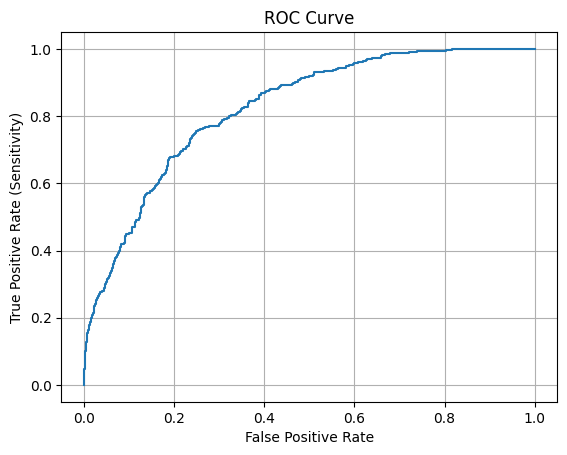

Best threshold: 0.2662944495677948
Sensitivity at best threshold: 0.7564102564102564
Specificity at best threshold: 0.7517173699705594


In [35]:
## Improve model
# metrics are decent, but sensitivity is low; would rather improve sensitivity over specificity
    # and identify those who churn over those who don't

# Previous metrics
# [[898 121]
 [198 192]]

#Accuracy: 0.7736
#Precision: 0.6134
#Sensitivity: 0.4923
#Specificity: 0.8813
#F1 Score: 0.5462

# 1) Optimize threshold to catch more positives and balance sensitivity & specificity
# 2) Increase epochs

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import numpy as np

fpr, tpr, thresholds = roc_curve(y_test, pred_raw)
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
best_threshold = thresholds[best_idx]

plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve')
plt.grid(True)
plt.show()

print(f"Best threshold: {best_threshold}")
print(f"Sensitivity at best threshold: {tpr[best_idx]}")
print(f"Specificity at best threshold: {1 - fpr[best_idx]}")

In [ ]:
## Save model
model.save("churn_model.h5")
#model.load_model("churn_model.h5")